# Train with Simple Return Reward

This notebook shows how to train agents using the **Simple Return** reward function.

This is your original baseline implementation - the simplest possible reward.

## What is Simple Return?

- Just the portfolio log return itself (no risk adjustment)
- Scaled by √52 for training stability
- Pure return maximization - no Sharpe, no penalties
- Simplest baseline to compare against more sophisticated rewards

## Formula
`reward = portfolio_return * √52`

## Setup

In [2]:
from train import train, train_all_algos, train_both_agents
from utils import print_results, compare_results, save_results
from config import get_config
import matplotlib.pyplot as plt
import pandas as pd

print("✓ Imports ready!")

✓ Imports ready!


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


## 1. Train Technical Agent

Train technical agent with Simple Return reward using PPO.

In [3]:
# Train with PPO
result_tech = train(
    agent_type='technical',
    algorithm='PPO',
    reward_type='simple_return',
    verbose=True
)

print(f"\n✓ Test Sharpe: {result_tech['test_sharpe']:.3f}")


Training: TECHNICAL - SIMPLE_RETURN - PPO
Gamma: 0.9
Softmax temp: 1.0
Patience: 15
Environment: 201 dates, 7 assets, 20 features
Transaction cost: 25.0 bps
Using cpu device

Training for 300,000 steps...
-----------------------------
| time/              |      |
|    fps             | 1116 |
|    iterations      | 1    |
|    time_elapsed    | 1    |
|    total_timesteps | 2048 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 1102        |
|    iterations           | 2           |
|    time_elapsed         | 3           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.012060279 |
|    clip_fraction        | 0.113       |
|    clip_range           | 0.2         |
|    entropy_loss         | -9.93       |
|    explained_variance   | -0.133      |
|    learning_rate        | 0.0003      |
|    loss                 | -0.0432   

## 2. Train Sentiment Agent

In [4]:
# Train with PPO
result_sent = train(
    agent_type='sentiment',
    algorithm='PPO',
    reward_type='simple_return',
    verbose=True
)

print(f"\n✓ Test Sharpe: {result_sent['test_sharpe']:.3f}")


Training: SENTIMENT - SIMPLE_RETURN - PPO
Gamma: 0.9
Softmax temp: 1.0
Patience: 15
Environment: 196 dates, 7 assets, 12 features
Transaction cost: 25.0 bps
Using cpu device

Training for 300,000 steps...
-----------------------------
| time/              |      |
|    fps             | 1312 |
|    iterations      | 1    |
|    time_elapsed    | 1    |
|    total_timesteps | 2048 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 1236        |
|    iterations           | 2           |
|    time_elapsed         | 3           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.011907431 |
|    clip_fraction        | 0.122       |
|    clip_range           | 0.2         |
|    entropy_loss         | -9.94       |
|    explained_variance   | -0.434      |
|    learning_rate        | 0.0003      |
|    loss                 | -0.0418   

## 3. Compare Technical vs Sentiment


SIMPLE RETURN COMPARISON (PPO)
    Agent  Train Sharpe  Val Sharpe  Test Sharpe
Technical      1.857765    2.326895     1.282936
Sentiment     -0.328403    2.265432     1.041468


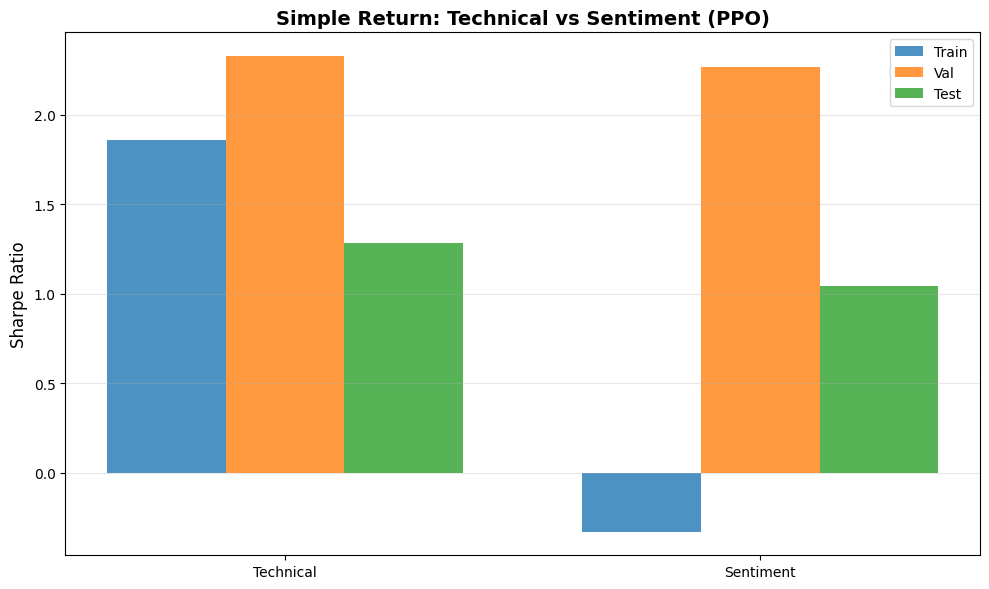

In [5]:
# Create comparison
comparison_data = {
    'Agent': ['Technical', 'Sentiment'],
    'Train Sharpe': [result_tech['train_sharpe'], result_sent['train_sharpe']],
    'Val Sharpe': [result_tech['val_sharpe'], result_sent['val_sharpe']],
    'Test Sharpe': [result_tech['test_sharpe'], result_sent['test_sharpe']]
}

df_comparison = pd.DataFrame(comparison_data)
print("\n" + "="*60)
print("SIMPLE RETURN COMPARISON (PPO)")
print("="*60)
print(df_comparison.to_string(index=False))
print("="*60)

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(df_comparison))
width = 0.25

ax.bar([i - width for i in x], df_comparison['Train Sharpe'], width, label='Train', alpha=0.8)
ax.bar(x, df_comparison['Val Sharpe'], width, label='Val', alpha=0.8)
ax.bar([i + width for i in x], df_comparison['Test Sharpe'], width, label='Test', alpha=0.8)

ax.set_ylabel('Sharpe Ratio', fontsize=12)
ax.set_title('Simple Return: Technical vs Sentiment (PPO)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df_comparison['Agent'])
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Try All Algorithms - Technical Agent

Compare PPO, SAC, and A2C for the technical agent.

In [6]:
# Technical agent - all algorithms
print("\n" + "="*70)
print("Training TECHNICAL agent with all algorithms")
print("="*70)

tech_results = train_all_algos(
    agent_type='technical',
    reward_type='simple_return',
    verbose=True
)


Training TECHNICAL agent with all algorithms

Training TECHNICAL with ALL algorithms
Reward: SIMPLE_RETURN

PPO: Test Sharpe = 1.064

SAC: Test Sharpe = 1.079

A2C: Test Sharpe = 1.129

COMPARISON TABLE
agent_type algorithm   reward_type  train_sharpe  val_sharpe  test_sharpe  gamma  softmax_temperature  transaction_cost
 technical       A2C simple_return      1.519378    2.593544     1.128519    0.9                  1.0            0.0025
 technical       SAC simple_return      0.371774    2.263452     1.079251    0.9                  1.0            0.0025
 technical       PPO simple_return      0.516708    2.256690     1.063545    0.9                  1.0            0.0025


🏆 Best: A2C (Test Sharpe: 1.129)


## 5. Try All Algorithms - Sentiment Agent

In [7]:
# Sentiment agent - all algorithms
print("\n" + "="*70)
print("Training SENTIMENT agent with all algorithms")
print("="*70)

sent_results = train_all_algos(
    agent_type='sentiment',
    reward_type='simple_return',
    verbose=True
)


Training SENTIMENT agent with all algorithms

Training SENTIMENT with ALL algorithms
Reward: SIMPLE_RETURN

PPO: Test Sharpe = 1.046

SAC: Test Sharpe = 1.049

A2C: Test Sharpe = 0.516

COMPARISON TABLE
agent_type algorithm   reward_type  train_sharpe  val_sharpe  test_sharpe  gamma  softmax_temperature  transaction_cost
 sentiment       SAC simple_return      0.900989    2.271175     1.048994    0.9                  1.0            0.0025
 sentiment       PPO simple_return      1.029175    2.259997     1.045668    0.9                  1.0            0.0025
 sentiment       A2C simple_return      2.415881    2.760249     0.515937    0.9                  1.0            0.0025


🏆 Best: SAC (Test Sharpe: 1.049)


## 6. Compare Results

In [9]:
# Combine all results
all_results = tech_results + sent_results

# Show comparison
df = compare_results(all_results)

# Summary
print("\n" + "="*70)
print("SUMMARY")
print("="*70)

best_tech = max(tech_results, key=lambda x: x['test_sharpe'])
best_sent = max(sent_results, key=lambda x: x['test_sharpe'])

print(f"\nBest Technical: {best_tech['algorithm']} - Test Sharpe = {best_tech['test_sharpe']:.3f}")
print(f"Best Sentiment: {best_sent['algorithm']} - Test Sharpe = {best_sent['test_sharpe']:.3f}")


COMPARISON TABLE
agent_type algorithm   reward_type  train_sharpe  val_sharpe  test_sharpe  gamma  softmax_temperature  transaction_cost
 technical       A2C simple_return      1.519378    2.593544     1.128519    0.9                  1.0            0.0025
 technical       SAC simple_return      0.371774    2.263452     1.079251    0.9                  1.0            0.0025
 technical       PPO simple_return      0.516708    2.256690     1.063545    0.9                  1.0            0.0025
 sentiment       SAC simple_return      0.900989    2.271175     1.048994    0.9                  1.0            0.0025
 sentiment       PPO simple_return      1.029175    2.259997     1.045668    0.9                  1.0            0.0025
 sentiment       A2C simple_return      2.415881    2.760249     0.515937    0.9                  1.0            0.0025


SUMMARY

Best Technical: A2C - Test Sharpe = 1.129
Best Sentiment: SAC - Test Sharpe = 1.049


In [10]:
# Save all results
results_dict = {
    'approach': 'simple_return',
    'technical_results': tech_results,
    'sentiment_results': sent_results,
    'best_technical': best_tech,
    'best_sentiment': best_sent
}

save_results(results_dict, 'results/simple_return_results.json')

✓ Results saved to: results/simple_return_results.json


## 📊 Understanding Simple Return Reward

The Simple Return reward is the most basic reward function.

### Formula (from rewards.py):
```python
# Just the return itself, scaled for training stability
reward = portfolio_return * sqrt(52)
reward = clip(reward, -10.0, 10.0)  # Bounded for stability
```

### Characteristics:
- **No risk adjustment** - Only cares about returns, not volatility
- **No memory** - Each reward is independent
- **Simplest baseline** - Minimal assumptions
- **Fast training** - No statistics to track

### Expected Behavior:
- ⚠️ May learn high-volatility strategies
- ⚠️ No explicit diversification incentive
- ⚠️ May overfit to training period
- ✅ Can sometimes match Sharpe-based rewards if agent naturally learns risk control

### When to Use:
- ✅ As a baseline to compare against
- ✅ When you want pure return maximization
- ✅ When risk is controlled elsewhere (e.g., position limits)
- ✅ To test if risk adjustment actually helps
- ❌ Not recommended for production without additional risk controls